In [22]:
print(os.listdir(DATASET_PATH))

['A', 'B', 'C', 'F', 'L', 'O', 'Q', 'V']


In [2]:
#RUN IF NOT ALREADY INSTALLED
import numpy as np
print("NumPy:", np.__version__)

import tensorflow as tf
print("TensorFlow:", tf.__version__)

import cv2
print("OpenCV:", cv2.__version__)

import mediapipe as mp
print("MediaPipe:", mp.__version__)
print(hasattr(mp, "solutions"))

NumPy: 1.26.4

TensorFlow: 2.15.0
OpenCV: 4.13.0
MediaPipe: 0.10.10
True


In [2]:
#MobileNet Model Training (Not necessary to run unless you want to train the MobileNet data)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import pickle

DATASET_PATH = "asl_subset"
IMG_SIZE = 128
BATCH_SIZE = 32

selected_classes = ["A", "B", "C", "Q", "V", "L", "Y", "F", "O"]

In [3]:
#MobileNet Model Training (Not necessary to run unless you want to train the MobileNet data)
import os
import shutil

source = DATASET_PATH
target = "sota_subset"

if os.path.exists(target):
    shutil.rmtree(target)

os.makedirs(target, exist_ok=True)

for cls in selected_classes:
    src_path = os.path.join(source, cls)
    dst_path = os.path.join(target, cls)

    if os.path.exists(src_path):
        shutil.copytree(src_path, dst_path)
    else:
        print("Missing:", cls)

SOTA_DATASET_PATH = target

In [3]:
#MobileNet Model Training (Not necessary to run unless you want to train the MobileNet data)
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    SOTA_DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    SOTA_DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

class_names = list(train_data.class_indices.keys())
print(class_names)

Found 21600 images belonging to 9 classes.
Found 5400 images belonging to 9 classes.
['A', 'B', 'C', 'F', 'L', 'O', 'Q', 'V', 'Y']


In [4]:
#MobileNet Model Training (Not necessary to run unless you want to train the MobileNet data)
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

mobilenet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

mobilenet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()



9406464/9406464 [==============================] - 1s 0us/step

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_128 (Func  (None, 4, 4, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 9)                 1161      
                                                        

In [5]:
#MobileNet Model Training (Not necessary to run unless you want to train the MobileNet data)
mobilenet_history = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10


675/675 [==============================] - 133s 192ms/step - loss: 0.0847 - accuracy: 0.9741 - val_loss: 0.1154 - val_accuracy: 0.9585
Epoch 2/10
675/675 [==============================] - 119s 176ms/step - loss: 0.0102 - accuracy: 0.9972 - val_loss: 0.2229 - val_accuracy: 0.9398
Epoch 3/10
675/675 [==============================] - 118s 174ms/step - loss: 0.0069 - accuracy: 0.9982 - val_loss: 0.0675 - val_accuracy: 0.9780
Epoch 4/10
675/675 [==============================] - 117s 174ms/step - loss: 0.0088 - accuracy: 0.9973 - val_loss: 0.0998 - val_accuracy: 0.9689
Epoch 5/10
675/675 [==============================] - 113s 168ms/step - loss: 0.0098 - accuracy: 0.9967 - val_loss: 0.1223 - val_accuracy: 0.9628
Epoch 6/10
675/675 [==============================] - 114s 168ms/step - loss: 0.0040 - accuracy: 0.9987 - val_loss: 0.1471 - val_accuracy: 0.9598
Epoch 7/10
675/675 [==============================] - 112s 165ms/step - loss: 0.0085 - accuracy: 0.9974 - val_loss: 0.1372

In [6]:
#MobileNet Model Training (Not necessary to run unless you want to train the MobileNet data)
mobilenet_model.save("mobilenetv2_asl_model.keras")

with open("mobilenet_history.pkl", "wb") as f:
    pickle.dump(mobilenet_history.history, f)

In [1]:
#LandmarkMLP StartHere RUN THIS SECTION
import os, cv2, random, pickle
import numpy as np
import tensorflow as tf
import mediapipe as mp
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

DATASET_PATH = "asl_subset"
#DATASET_PATH = "debas" #IMPORTANT TO CHANGE TO THIS DATA SET IF YOU WANT TO RUN DATASET2
selected_classes = ["A", "B", "C", "Q", "V", "L", "Y", "F", "O"]
MAX_IMAGES_PER_CLASS = 500
EPOCHS = 20

In [2]:
#RUN THIS SECTION
mp_hands = mp.solutions.hands

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

X, y = [], []

def extract_landmarks(image):
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb)

    if not results.multi_hand_landmarks:
        return None

    hand = results.multi_hand_landmarks[0]
    wrist = hand.landmark[0]

    landmarks = []
    for lm in hand.landmark:
        landmarks.extend([lm.x - wrist.x, lm.y - wrist.y, lm.z - wrist.z])

    return landmarks

for class_id, cls in enumerate(selected_classes):
    folder = os.path.join(DATASET_PATH, cls)
    images = os.listdir(folder)
    images = random.sample(images, min(len(images), MAX_IMAGES_PER_CLASS))

    print("Processing:", cls)

    for img_name in images:
        img = cv2.imread(os.path.join(folder, img_name))
        if img is None:
            continue

        lm = extract_landmarks(img)
        if lm is not None:
            X.append(lm)
            y.append(class_id)

hands.close()

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X:", X.shape)
print("y:", y.shape)

Processing: A
Processing: B
Processing: C
Processing: Q
Processing: V
Processing: L
Processing: Y
Processing: F
Processing: O
X: (3530, 63)
y: (3530,)


In [10]:
#RUN THIS ONLY IF THE SOUNDS AREN'T GENERATING IN YOUR COMPUTER. THE FILES SHOULD ALREADY BE IN THE SOUND FOLDER. 
import os
import numpy as np
import scipy.io.wavfile as wav

os.makedirs("sounds", exist_ok=True)

sample_rate = 44100

def create_tone(filename, frequency, duration=0.35):
    t = np.linspace(0, duration, int(sample_rate * duration), False)
    wave = np.sin(2 * np.pi * frequency * t)
    audio = (wave * 32767).astype(np.int16)
    wav.write(filename, sample_rate, audio)

note_frequency = {
    "A": 440.00,   # A
    "B": 493.88,   # B
    "C": 261.63,   # C
    "V": 293.66,   # D
    "Q": 329.63,   # E
    "L": 349.23,   # F
    "Y": 392.00,   # G
}

for gesture, freq in note_frequency.items():
    path = f"sounds/{gesture}.wav"

    if not os.path.exists(path):
        create_tone(path, freq)
        print("Created:", path)
    else:
        print("Already exists:", path)

print("Sounds ready.")

Already exists: sounds/A.wav
Already exists: sounds/B.wav
Already exists: sounds/C.wav
Already exists: sounds/V.wav
Already exists: sounds/Q.wav
Already exists: sounds/L.wav
Already exists: sounds/Y.wav
Sounds ready.


In [3]:
#RUN THIS SECTION
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

landmark_model = models.Sequential([
    layers.Input(shape=(63,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(selected_classes), activation="softmax")
])

landmark_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

landmark_history = landmark_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=32,
    shuffle=True
)



Epoch 1/20


89/89 [==============================] - 1s 3ms/step - loss: 1.6385 - accuracy: 0.5220 - val_loss: 0.9234 - val_accuracy: 0.8272
Epoch 2/20
89/89 [==============================] - 0s 2ms/step - loss: 0.6551 - accuracy: 0.8520 - val_loss: 0.3101 - val_accuracy: 0.9646
Epoch 3/20
89/89 [==============================] - 0s 2ms/step - loss: 0.3277 - accuracy: 0.9288 - val_loss: 0.1538 - val_accuracy: 0.9773
Epoch 4/20
89/89 [==============================] - 0s 2ms/step - loss: 0.1880 - accuracy: 0.9685 - val_loss: 0.0987 - val_accuracy: 0.9802
Epoch 5/20
89/89 [==============================] - 0s 2ms/step - loss: 0.1333 - accuracy: 0.9763 - val_loss: 0.0722 - val_accuracy: 0.9844
Epoch 6/20
89/89 [==============================] - 0s 2ms/step - loss: 0.1010 - accuracy: 0.9834 - val_loss: 0.0559 - val_accuracy: 0.9915
Epoch 7/20
89/89 [==============================] - 0s 2ms/step - loss: 0.0839 - accuracy: 0.9841 - val_loss: 0.0438 - val_accuracy: 0.9929
Epoch 8/20
89/89

In [4]:
#RUN THIS SECTION
landmark_model.save("asl_landmark_model.keras")

with open("asl_landmark_classes.txt", "w") as f:
    for cls in selected_classes:
        f.write(cls + "\n")

with open("landmark_history.pkl", "wb") as f:
    pickle.dump(landmark_history.history, f)

print("Landmark model saved.")

Landmark model saved.


In [5]:
#DEMO SECTION - RUN THIS SECTION
import os, cv2, time
import numpy as np
import tensorflow as tf
import pygame
import mediapipe as mp

pygame 2.6.1 (SDL 2.28.4, Python 3.10.20)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [6]:
#DEMO SECTION - RUN THIS SECTION
model = tf.keras.models.load_model("asl_landmark_model.keras") #If you want to use the mobilenet model use the third line
#model = tf.keras.models.load_model("mobilenetv2_asl_model.keras")
with open("asl_landmark_classes.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]

pygame.mixer.init()

sounds = {}
for cls in class_names:
    path = f"sounds/{cls}.wav"
    if os.path.exists(path):
        sounds[cls] = pygame.mixer.Sound(path)

print("Loaded:", class_names)

Loaded: ['A', 'B', 'C', 'Q', 'V', 'L', 'Y', 'F', 'O']


In [7]:
#DEMO SECTION - RUN THIS SECTION
gesture_to_note = {
    "A": "A",
    "B": "B",
    "C": "C",
    "L": "F",
    "Y": "G",
    "V": "D",
    "Q": "E",
    "F": "REST",
    "O": "TEMPO"
}

white_keys = ["A", "B", "C", "D", "E", "F", "G"]

def draw_piano(active_gesture=None, tempo_bpm=120):
    active_note = gesture_to_note.get(active_gesture, None)

    white_w = 90
    white_h = 230
    black_w = 55
    black_h = 140

    piano = np.ones((340, white_w * len(white_keys), 3), dtype=np.uint8) * 230

    for i, note in enumerate(white_keys):
        x1 = i * white_w
        x2 = x1 + white_w

        color = (255, 255, 255)
        if note == active_note:
            color = (120, 255, 120)

        cv2.rectangle(piano, (x1, 30), (x2, 30 + white_h), color, -1)
        cv2.rectangle(piano, (x1, 30), (x2, 30 + white_h), (0, 0, 0), 2)
        cv2.putText(piano, note, (x1 + 30, 245),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

    black_keys = {
        "C#": 0.65,
        "D#": 1.65,
        "F#": 3.65,
        "G#": 4.65,
        "A#": 5.65
    }

    for note, pos in black_keys.items():
        x_center = int(pos * white_w)
        x1 = x_center - black_w // 2
        x2 = x_center + black_w // 2
        cv2.rectangle(piano, (x1, 30), (x2, 30 + black_h), (20, 20, 20), -1)

    cv2.putText(piano, f"Tempo: {tempo_bpm} BPM", (20, 320),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

    return piano


def extract_landmarks_from_results(results):
    if not results.multi_hand_landmarks:
        return None

    hand = results.multi_hand_landmarks[0]
    wrist = hand.landmark[0]

    landmarks = []
    for lm in hand.landmark:
        landmarks.extend([lm.x - wrist.x, lm.y - wrist.y, lm.z - wrist.z])

    return np.array(landmarks, dtype=np.float32)


def get_pinch_distance(hand_landmarks):
    thumb_tip = hand_landmarkselandmark[4]

In [8]:
#DEMO SECTION - RUN THIS SECTION
def extract_landmarks_from_results(results):
    if not results.multi_hand_landmarks:
        return None

    hand = results.multi_hand_landmarks[0]
    wrist = hand.landmark[0]

    landmarks = []
    for lm in hand.landmark:
        landmarks.extend([lm.x - wrist.x, lm.y - wrist.y, lm.z - wrist.z])

    return np.array(landmarks, dtype=np.float32)


def get_pinch_distance(hand_landmarks):
    thumb_tip = hand_landmarks.landmark[4]
    index_tip = hand_landmarks.landmark[8]

    dx = thumb_tip.x - index_tip.x
    dy = thumb_tip.y - index_tip.y

    return np.sqrt(dx * dx + dy * dy)

In [9]:
#DEMO SECTION - RUN THIS SECTION
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
)

cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

prediction_buffer = []
buffer_size = 12

last_prediction = None
last_play_time = 0

tempo_bpm = 120
min_bpm = 60
max_bpm = 180

confidence_threshold = 0.90

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb)

    gesture = "No hand"
    confidence = 0.0
    active_key = None

    cooldown = 60 / tempo_bpm

    if results.multi_hand_landmarks:
        hand_landmarks = results.multi_hand_landmarks[0]
        mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

        landmarks = extract_landmarks_from_results(results)

        if landmarks is not None:
            input_data = np.expand_dims(landmarks, axis=0)

            prediction = model.predict(input_data, verbose=0)[0]
            raw_class_id = np.argmax(prediction)

            prediction_buffer.append(raw_class_id)
            if len(prediction_buffer) > buffer_size:
                prediction_buffer.pop(0)

            stable_class_id = max(set(prediction_buffer), key=prediction_buffer.count)

            gesture = class_names[stable_class_id]
            confidence = prediction[stable_class_id]

            if confidence > confidence_threshold:
                if gesture == "O":
                    pinch = get_pinch_distance(hand_landmarks)

                    tempo_bpm = int(np.interp(
                        pinch,
                        [0.03, 0.20],
                        [min_bpm, max_bpm]
                    ))

                    tempo_bpm = max(min_bpm, min(max_bpm, tempo_bpm))
                    active_key = None

                elif gesture == "F":
                    active_key = None
                    last_prediction = gesture

                else:
                    active_key = gesture
                    now = time.time()

                    if gesture != last_prediction or now - last_play_time > cooldown:
                        if gesture in sounds:
                            sounds[gesture].play()

                        last_prediction = gesture
                        last_play_time = now
            else:
                last_prediction = None

    piano = draw_piano(active_key, tempo_bpm)
    piano = cv2.resize(piano, (frame.shape[1], 180))

    cv2.putText(frame, f"Gesture: {gesture} ({confidence:.2f})",
                (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1,
                (0, 255, 0), 2)

    if gesture == "O":
        cv2.putText(frame, "TEMPO MODE: pinch open/close",
                    (30, 90), cv2.FONT_HERSHEY_SIMPLEX,
                    0.8, (0, 255, 255), 2)

    combined = np.vstack((frame, piano))
    cv2.imshow("ASL Landmark Piano", combined)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
hands.close()
cv2.destroyAllWindows()

In [10]:
#RESULTS SECTION - RUN THIS SECTION
# Landmark
import pickle
with open("landmark_history.pkl", "wb") as f:
    pickle.dump(landmark_history.history, f)

# MobileNet
#with open("mobilenet_history.pkl", "wb") as f:
    #pickle.dump(mobilenet_history.history, f)

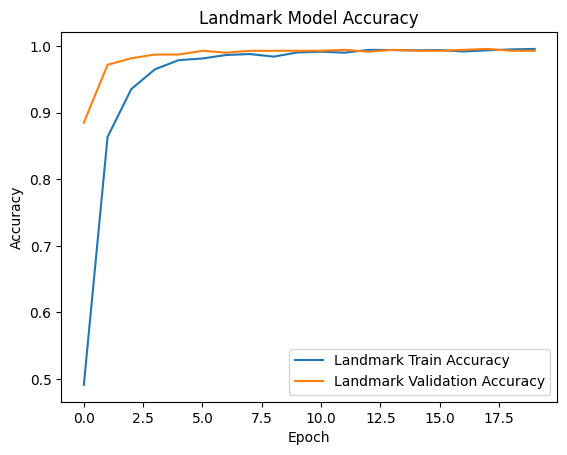

In [11]:
#RESULTS SECTION - RUN THIS SECTION
#Graphs - Landmark Model Accuracy
import pickle
import matplotlib.pyplot as plt

with open("landmark_history.pkl", "rb") as f:
    landmark_history_data = pickle.load(f)

plt.plot(landmark_history_data["accuracy"], label="Landmark Train Accuracy")
plt.plot(landmark_history_data["val_accuracy"], label="Landmark Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Landmark Model Accuracy")
plt.legend()
plt.show()

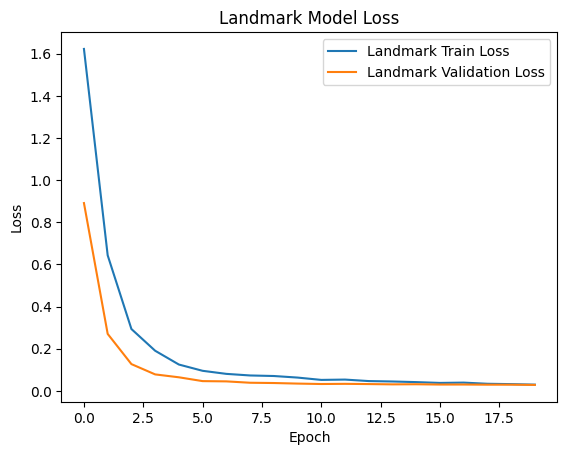

In [12]:
#RESULTS SECTION - RUN THIS SECTION
plt.plot(landmark_history_data["loss"], label="Landmark Train Loss")
plt.plot(landmark_history_data["val_loss"], label="Landmark Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Landmark Model Loss")
plt.legend()
plt.show()

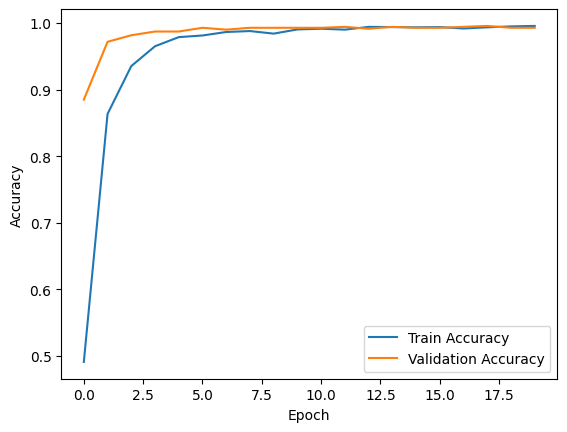

In [13]:
#RESULTS SECTION - RUN THIS SECTION
with open("landmark_history.pkl", "rb") as f:
    landmark_history_data = pickle.load(f)

plt.plot(landmark_history.history["accuracy"], label="Train Accuracy")
plt.plot(landmark_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

23/23 [==============================] - 0s 3ms/step


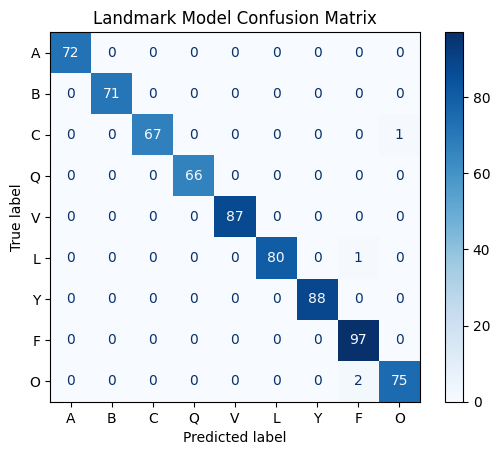

In [19]:
#RESULTS SECTION - RUN THIS SECTION

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_pred_probs = landmark_model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=selected_classes
)

disp.plot(cmap="Blues")
plt.title("Landmark Model Confusion Matrix")
plt.show()

In [36]:
#RESULTS SECTION - RUN THIS SECTION
import pickle

with open("landmark_history.pkl", "wb") as f:
    pickle.dump(landmark_history.history, f)

In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_val, y_pred, average="macro")
print("Macro F1:", f1)

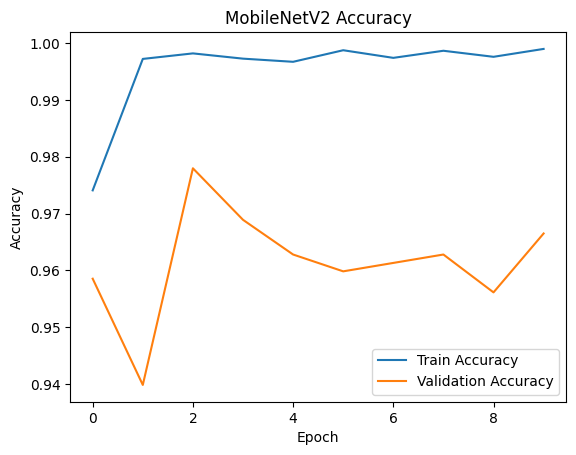

In [17]:
#MobileNet Results Only

import matplotlib.pyplot as plt

plt.plot(mobilenet_history.history["accuracy"], label="Train Accuracy")
plt.plot(mobilenet_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Accuracy")
plt.legend()
plt.show()


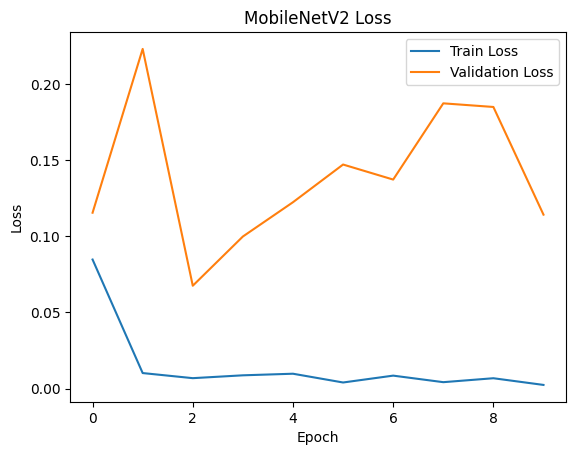

In [20]:
#MobileNet Results Only

import pickle
import matplotlib.pyplot as plt

with open("mobilenet_history.pkl", "rb") as f:
    mobilenet_history_data = pickle.load(f)

plt.plot(mobilenet_history_data["loss"], label="Train Loss")
plt.plot(mobilenet_history_data["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Loss")
plt.legend()
plt.show()

169/169 [==============================] - 26s 141ms/step


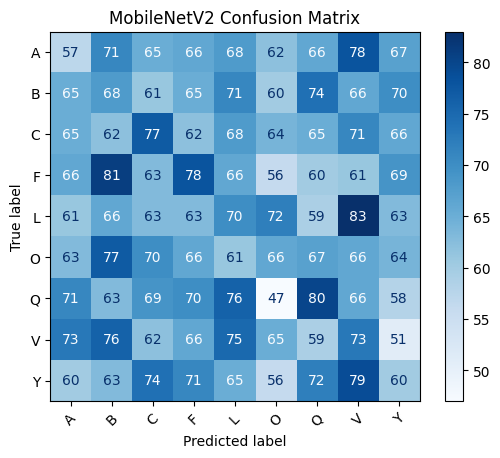

In [18]:
#MobileNet Results Only

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Get predictions
y_pred_probs = mobilenet_model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(val_data.class_indices.keys())
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("MobileNetV2 Confusion Matrix")
plt.show()

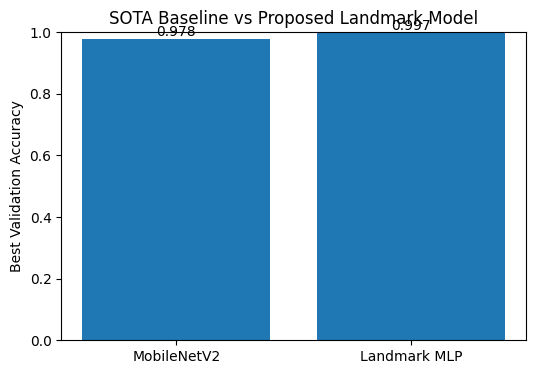

In [14]:
#MobileNet Results Comparison with the MLP Landmark Model


with open("landmark_history.pkl", "rb") as f:
    landmark_history_data = pickle.load(f)

with open("mobilenet_history.pkl", "rb") as f:
    mobilenet_history_data = pickle.load(f)

mobilenet_best = max(mobilenet_history_data["val_accuracy"])
landmark_best = max(landmark_history_data["val_accuracy"])

models = ["MobileNetV2", "Landmark MLP"]
scores = [mobilenet_best, landmark_best]

plt.figure(figsize=(6,4))
bars = plt.bar(models, scores)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.01,
        f"{yval:.3f}",
        ha="center"
    )

plt.ylabel("Best Validation Accuracy")
plt.title("SOTA Baseline vs Proposed Landmark Model")
plt.ylim(0, 1)
plt.show()

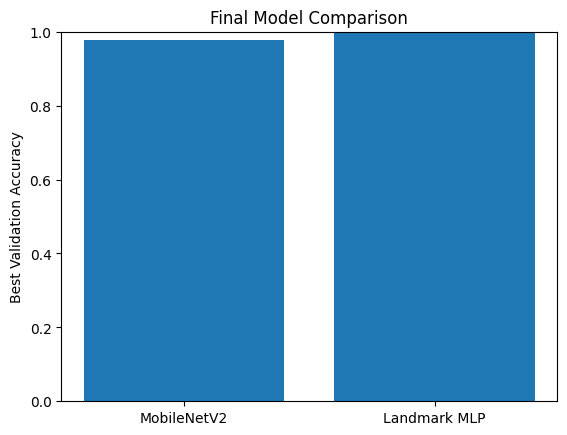

In [15]:
#DO NOT RUN THIS SECTION
landmark_best = max(landmark_history_data["val_accuracy"])
mobilenet_best = max(mobilenet_history_data["val_accuracy"])

plt.bar(["MobileNetV2", "Landmark MLP"], [mobilenet_best, landmark_best])
plt.ylabel("Best Validation Accuracy")
plt.title("Final Model Comparison")
plt.ylim(0,1)
plt.show()